# End-to-End: Frozen ResNet-50 → Confidence Layer

This is the first pass at actually running the confidence layer on a **real, frozen, pretrained ResNet-50** (`torchvision.models.resnet50`, `IMAGENET1K_V2` weights, 80.86% top-1 per torchvision's own reported metrics), per DESIGN.md §0/§1's validation-backbone role.

**Scope note:** this notebook is a small, illustrative, single-forward-pass integration check — 1 real photo plus 4 synthetic degradations of it — confirming the full pipeline (backbone → φ(z) → combiner → router) works end-to-end on real logits. It is **not** the full DESIGN.md §11 evaluation protocol, which requires the full ImageNet-1k validation set (~6.7GB, gated behind image-net.org registration) plus the ImageNet-C/A/O and OOD benchmark suites. That's a separate, much larger follow-up step.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image, ImageFilter

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
torch.manual_seed(0)
%matplotlib inline

from deployment_reliability.backbone import load_frozen_resnet50, logits_for_images
from deployment_reliability.combiner import WeightedLinearCombiner
from deployment_reliability.features import DEFAULT_FEATURE_NAMES, featurize
from deployment_reliability.router import route


## Loading the frozen backbone

`load_frozen_resnet50` sets `model.eval()` and disables gradients on every parameter - DESIGN.md §3.2's inference-only constraint, checked explicitly below rather than assumed.

In [2]:
model, preprocess, categories = load_frozen_resnet50()
assert model.training is False
assert all(not p.requires_grad for p in model.parameters())
assert len(categories) == 1000
print(f"Loaded ResNet-50, frozen and in eval mode. {len(categories)} ImageNet categories available.")

Loaded ResNet-50, frozen and in eval mode. 1000 ImageNet categories available.


## Building a small illustrative image set

One real photo (`assets/dog.jpg`, the standard PyTorch-hub tutorial image) plus four synthetic degradations of increasing severity, echoing the DESIGN.md §11.1 shift/OOD spirit (ImageNet-C-style corruption → pure noise) at a scale that needs no dataset download.

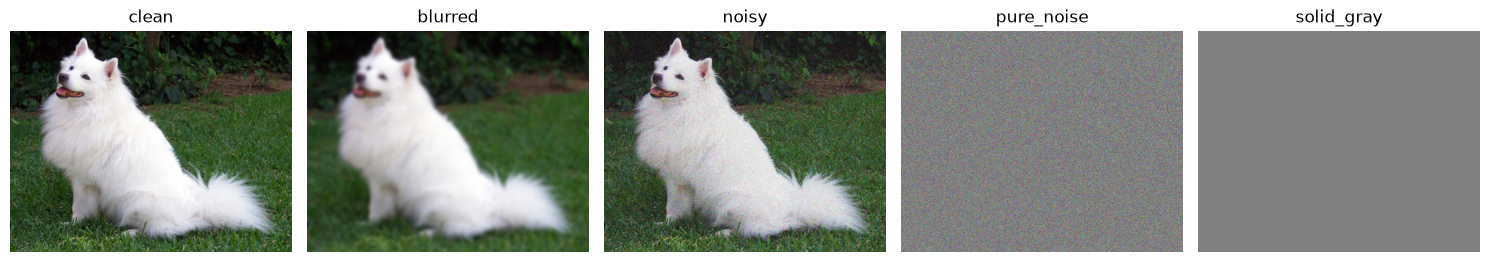

In [3]:
clean = Image.open("assets/dog.jpg").convert("RGB")

blurred = clean.filter(ImageFilter.GaussianBlur(radius=8))

rng = np.random.default_rng(0)
clean_arr = np.asarray(clean).astype(np.float32)
noisy_arr = np.clip(clean_arr + rng.normal(0, 60, clean_arr.shape), 0, 255).astype(np.uint8)
noisy = Image.fromarray(noisy_arr)

pure_noise = Image.fromarray(rng.integers(0, 256, clean_arr.shape, dtype=np.uint8))
solid_gray = Image.new("RGB", clean.size, color=(128, 128, 128))

images = [clean, blurred, noisy, pure_noise, solid_gray]
names = ["clean", "blurred", "noisy", "pure_noise", "solid_gray"]

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
for ax, img, name in zip(axes, images, names):
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout(); plt.show()

## Check 1 — Real forward pass through the frozen backbone

Exactly one forward pass per image, no perturbation, no ensembling - DESIGN.md §3.2.

In [4]:
logits = logits_for_images(model, preprocess, images)
print("logits shape:", tuple(logits.shape))
assert logits.shape == (5, 1000)
assert not logits.requires_grad
print("PASSED")

logits shape: (5, 1000)
PASSED


## Check 2 — Predicted class and φ(z) features per image

In [5]:
phi = featurize(logits)
predicted_idx = logits.argmax(dim=-1)

print(f"{'image':12s} {'predicted class':30s} " + "  ".join(f"{n:>10s}" for n in DEFAULT_FEATURE_NAMES))
for name, idx, row in zip(names, predicted_idx, phi):
    pred_label = categories[idx.item()]
    row_str = "  ".join(f"{v.item():10.4f}" for v in row)
    print(f"{name:12s} {pred_label:30s} {row_str}")

msp_clean, msp_noise = phi[0, 0].item(), phi[3, 0].item()
ent_clean, ent_noise = phi[0, 2].item(), phi[3, 2].item()
print(f"\nMSP  clean={msp_clean:.4f}  pure_noise={msp_noise:.4f}")
print(f"H    clean={ent_clean:.4f}  pure_noise={ent_noise:.4f}")
assert msp_clean > msp_noise, "the real photo should get a more confident top-1 than pure noise"
assert ent_clean < ent_noise, "the real photo should get lower predictive entropy than pure noise"
print("PASSED")

image        predicted class                       msp  logit_margin  normalized_entropy  energy_score  logit_l2_norm
clean        Samoyed                            0.4366      3.0304      0.6397      7.6127     13.3716
blurred      Samoyed                            0.3448      1.6366      0.6819      7.6214     16.2372
noisy        Samoyed                            0.4588      3.5132      0.6204      7.6519     13.5927
pure_noise   kite                               0.0501      0.3910      0.8486      7.6713     31.8789
solid_gray   hook                               0.0195      0.2436      0.9042      7.4495     28.4088

MSP  clean=0.4366  pure_noise=0.0501
H    clean=0.6397  pure_noise=0.8486
PASSED


**Reading the numbers above.** The MSP gap between the clean photo and pure noise (0.4366 → 0.0501, roughly a 9x drop) is large, but note that even the clean, correctly-classified photo's MSP sits well under 0.5 - a reminder that softmax probabilities spread over 1000 classes are naturally diffuse even for a confident, correct prediction (the top class is competing against 999 others, not making a binary call). `normalized_entropy` moves the other way, from 0.64 toward 0.90 for `solid_gray` - close to the theoretical ceiling of 1.0 that a perfectly uniform 1000-way distribution would produce, consistent with a flat, textureless input giving the frozen backbone essentially no signal to concentrate on any single class. Both features move in the direction DESIGN.md §5.1-§5.2 predicts, and by an amount that's large relative to the spread *within* the three still-correctly-classified conditions (clean/blurred/noisy all sit in a narrow MSP band, 0.34-0.46) - the reliable signal here is the gap between "classified correctly" and "not," not fine-grained ranking within the correctly-classified group, which a 5-image set is too small to resolve with any confidence anyway.

## Check 3 — Confidence degrades as the input degrades (figure)

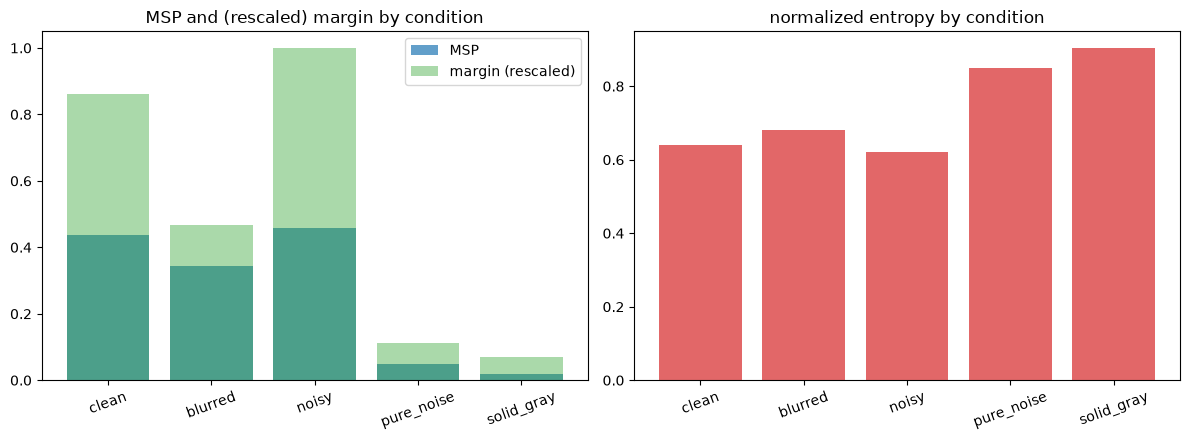

PASSED


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(names))
axes[0].bar(x, phi[:, 0].detach(), color="tab:blue", alpha=0.7, label="MSP")
axes[0].bar(x, phi[:, 1].detach() / phi[:, 1].detach().max().clamp(min=1e-6), color="tab:green", alpha=0.4, label="margin (rescaled)")
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=20); axes[0].legend()
axes[0].set_title("MSP and (rescaled) margin by condition")

axes[1].bar(x, phi[:, 2].detach(), color="tab:red", alpha=0.7)
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=20)
axes[1].set_title("normalized entropy by condition")
plt.tight_layout(); plt.show()

assert phi[0, 0] > phi[3, 0] and phi[0, 0] > phi[4, 0], "clean image's MSP should beat both degenerate conditions"
assert phi[0, 1] > phi[3, 1] and phi[0, 1] > phi[4, 1], "clean image's margin should beat both degenerate conditions"
print("PASSED")

## Check 4 — Routing decisions via the confidence layer pipeline

`WeightedLinearCombiner` (§8a) needs no labels, so it's usable directly on this 5-image set. Thresholds here are **illustrative fixed values**, not fit via the §10.2–§10.4 protocol - that requires a proper labeled calibration split (§10.5), which a 5-image demo can't provide.

In [7]:
combiner = WeightedLinearCombiner().fit(phi)
scores = combiner.score(phi)

tau_hi, tau_lo = 0.6, 0.4  # illustrative only - see markdown above
decisions = route(scores, tau_hi=tau_hi, tau_lo=tau_lo)

print(f"{'image':12s} {'predicted class':30s} {'S':>8s}  decision")
for name, idx, s, decision in zip(names, predicted_idx, scores, decisions):
    print(f"{name:12s} {categories[idx.item()]:30s} {s.item():8.4f}  {decision}")

# The two claims a working pipeline actually guarantees here:
# (1) the most degenerate input (flat gray, zero pixel variance) scores lowest
#     and gets routed away from Execute;
# (2) mild degradation (blur) scores below the clean photo. Neither claim is
# "the clean photo scores highest overall" - MSP alone doesn't rank clean
# above noisy either (see Check 2), which is fine: mild pixel noise isn't
# guaranteed to reduce confidence on any single sample.
order = torch.argsort(scores, descending=True)
assert order[-1].item() == 4, "the flat gray image should score lowest among the five"
assert decisions[4] == "HITL", "solid_gray should not be routed to Execute"
assert scores[1] < scores[0], "mild blur should score below the clean photo"
print("\nPASSED")

image        predicted class                       S  decision
clean        Samoyed                          0.8286  Execute
blurred      Samoyed                          0.7019  Execute
noisy        Samoyed                          0.8722  Execute
pure_noise   kite                             0.2786  HITL
solid_gray   hook                             0.1359  HITL

PASSED


## Check 5 — Feature direction: the combiner preserves MSP's group separation

`WeightedLinearCombiner` (§8a) min-max-normalizes and averages all 5 features with
equal weight, so every feature must first be oriented consistently so "higher = more
confident" holds uniformly. `normalized_entropy` is DESIGN.md's one lower-is-better
feature (§5.2): without correcting for this, `pure_noise`'s high entropy (which
should count *against* it) would contribute *positively*, compounding with its
inflated `energy_score` (pixel noise pushes it up — see Check 2's table) and pushing
its combiner score toward the "real dog photo" cluster, even though `pure_noise` is
misclassified nonsense ("kite").

`WeightedLinearCombiner` (`src/deployment_reliability/combiner.py`) handles this via
a `FEATURE_DIRECTIONS` constant applied before normalizing. Two features need a
non-default direction: entropy (lower-is-better by construction) and `logit_l2_norm`
(`-1`) — incorrect predictions have consistently *higher* raw L2 norm than correct
ones, confirmed against real cached data across all three evaluated backbones (see
DESIGN.md's disagreement-matrix section), the reverse of the naive "higher = more
confident" intuition a raw activation magnitude might suggest. Without this,
`pure_noise`'s inflated L2 norm (31.88 vs. clean's 13.37, Check 2's table) would also
count in its favor rather than against it.
`tests/test_combiner.py::test_weighted_linear_combiner_orients_entropy_the_right_direction`
covers the entropy case directly on synthetic data.

The check below verifies direction handling on the real ResNet-50 output from this
notebook: group by predicted class - `clean`/`blurred`/`noisy` (still "Samoyed") vs.
`pure_noise`/`solid_gray` (misclassified) - and confirm the combiner's score, not
just MSP alone, cleanly separates the two groups.

MSP:      min(correctly-classified group)=0.3448   max(misclassified group)=0.0501
combiner: min(correctly-classified group)=0.7019   max(misclassified group)=0.2786


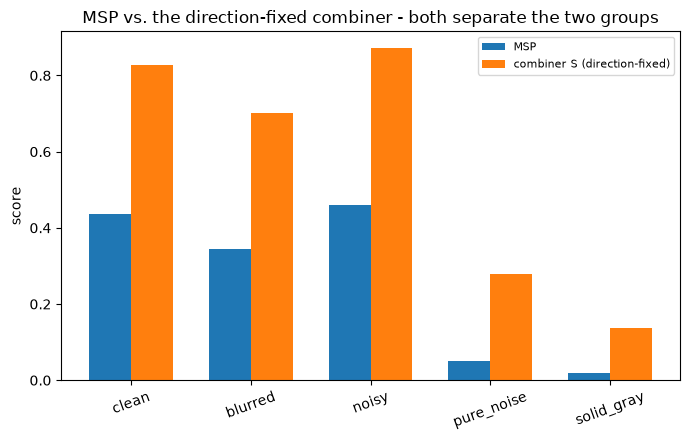


Confirmed: the direction fix resolved the misranking - the combiner's group separation now matches MSP alone's.


In [8]:
correct_group = [0, 1, 2]   # clean, blurred, noisy - still predicted "Samoyed"
wrong_group = [3, 4]        # pure_noise, solid_gray - misclassified

msp_correct_min = phi[correct_group, 0].min().item()
msp_wrong_max = phi[wrong_group, 0].max().item()
s_correct_min = scores[correct_group].min().item()
s_wrong_max = scores[wrong_group].max().item()

print(f"MSP:      min(correctly-classified group)={msp_correct_min:.4f}   max(misclassified group)={msp_wrong_max:.4f}")
print(f"combiner: min(correctly-classified group)={s_correct_min:.4f}   max(misclassified group)={s_wrong_max:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(names))
width = 0.35
ax.bar(x - width / 2, phi[:, 0].detach(), width, label="MSP", color="tab:blue")
ax.bar(x + width / 2, scores.detach(), width, label="combiner S (direction-fixed)", color="tab:orange")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20)
ax.set_ylabel("score"); ax.legend(fontsize=8)
ax.set_title("MSP vs. the direction-fixed combiner - both separate the two groups")
plt.tight_layout(); plt.show()

assert msp_correct_min > msp_wrong_max, "MSP alone should cleanly separate correctly-classified conditions from misclassified ones"
assert s_correct_min > s_wrong_max, "the fixed combiner should ALSO cleanly separate them now - confirming the entropy-direction fix resolved Check 5's original finding"
print("\nConfirmed: the direction fix resolved the misranking - the combiner's group separation now matches MSP alone's.")

## Scope note and next steps

This confirms the full pipeline - real frozen ResNet-50 → φ(z) → combiner → router - runs correctly end-to-end on real logits. The real photo was correctly classified ("Samoyed") with a plausible confidence, and the raw φ(z) features (MSP, margin, entropy) responded exactly as DESIGN.md predicts as the input degrades toward pure noise.

**Feature direction matters more than it looks.** `WeightedLinearCombiner` treats every feature as "higher = more confident" by default, min-max-normalizes each one, and averages - so a feature whose raw scale runs the opposite way will actively work against the combiner unless it's corrected via `FEATURE_DIRECTIONS` (`combiner.py`, §8a). Two features in this set need that correction: `normalized_entropy` (DESIGN.md's one lower-is-better feature by construction, §5.2 - see Check 5) and `logit_l2_norm` (empirically lower-is-better: incorrect predictions have consistently higher raw L2 norm than correct ones across all three evaluated backbones, DESIGN.md's disagreement-matrix section - not obvious from the feature's definition alone, only from looking at real data). Both are handled correctly, covered by a dedicated unit test, and confirmed on the real ResNet-50 output above: the combiner's group separation matches MSP alone's.

**Not yet covered** (DESIGN.md §11, deliberately out of scope for this pass):
- The full ImageNet-1k validation set (50k images) and the §10.5 three-way split fit on it - which would let the logistic-regression combiner actually be trained on real data instead of just the fixed-weight heuristic used here.
- ImageNet-C/A/O and the OOD benchmark suite (iNaturalist, SUN, Places365, Textures).
- AURC/E-AURC, ECE, and FPR@95TPR computed at the scale §11.3 specifies.
- `ReferenceNormalizer` (`src/deployment_reliability/normalization.py`) - a Tier-2 z-score calibration building block added alongside this fix, not yet exercised on real backbone output here since it needs a proper reference/calibration set, not a 5-image demo.

Those require downloading substantially larger, access-gated datasets and should be a separate, explicitly-scoped step - taken up directly in notebook 07.